[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/04_evaluation.ipynb)

# 04 — Results and How Far to Trust Them

**Question.** Which tilt configuration should be recommended, what does it change on the network, and how
robust is that conclusion?

**Inputs.** The newest run of each method and seed under `outputs/optim/`, the current radio map, and the
processed tables. **Outputs.** `reports/tables/04_evaluation/` and `reports/figures/04_evaluation/`.
No GPU is needed. Every table and figure is built by `src/evaluation/run.py`, the same code `task evaluate` runs.
The Multi-Agent Reinforcement Learning arm is not implemented, so the comparison covers TuRBO and the two baselines.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial

import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation.export import save_table
from src.evaluation.run import evaluate
from src.utils.plotting import save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/04_evaluation"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/04_evaluation"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

## 1. Comparability

Runs are compared only if they share the scenario, grid, solver settings, bands and KPI definition.

In [3]:
results = evaluate(cfg, in_colab=IN_COLAB)
checks = results["comparability_checks"]
print(f"{int(checks['Holds'].sum())} of {len(checks)} comparability checks hold")

21 of 21 comparability checks hold


## 2. KPI Scoreboard

Best configuration of each method, averaged over seeds, against the current configuration. A change within a KPI's
tolerance (`configs/kpi.yaml`) is reported as a tie.

,Method,KPI,Direction,Seeds,Current configuration,Mean,Standard deviation,95% CI lower,95% CI upper,Mean change,Verdict
0,Random search,Coverage hole rate,minimise,1,0.1768,0.1755,NaN,NaN,NaN,-0.0013,better
1,Random search,Co-band overlap rate,minimise,1,0.3212,0.3186,NaN,NaN,NaN,-0.0027,better
2,Random search,Served UE ratio,maximise,1,0.9065,0.9115,NaN,NaN,NaN,0.0050,better
3,Random search,Weak coverage rate,minimise,1,0.1739,0.1549,NaN,NaN,NaN,-0.0191,better
4,Random search,Cell-edge RSRP,maximise,1,-105.9248,-104.6967,NaN,NaN,NaN,1.2280,better
5,Random search,Coverage desirability,maximise,1,0.8227,0.8249,NaN,NaN,NaN,0.0022,better
6,Random search,Layer separation desirability,maximise,1,0.8886,0.9003,NaN,NaN,NaN,0.0117,better
7,Random search,"Served desirability, per tile",maximise,1,0.8568,0.8659,NaN,NaN,NaN,0.0091,better
8,Random search,Quality index,maximise,1,0.8499,0.8562,NaN,NaN,NaN,0.0063,better
9,Rule-based sweep,Coverage hole rate,minimise,1,0.1768,0.1719,NaN,NaN,NaN,-0.0049,better


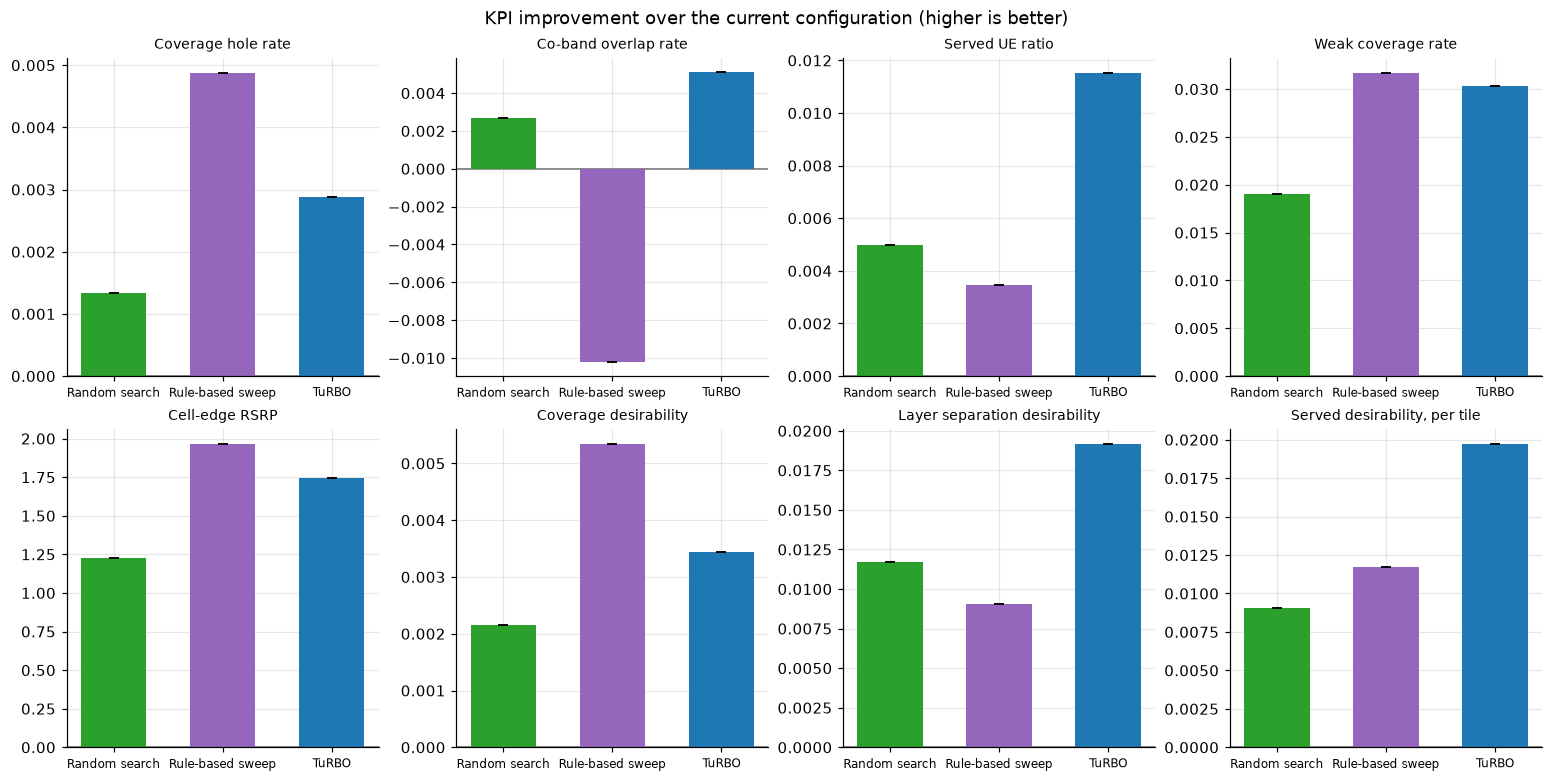

In [4]:
display(results["kpi_scoreboard"])
display(results["kpi_improvement"])

**Observations.** _To be written._

## 3. Did the Search Matter?

Each run's best score against the typical candidate it evaluated, and TuRBO against random search paired by seed.

In [5]:
display(results["winner_vs_candidates"])
display(results["paired_gain_turbo_vs_random"])

,Method,Seed,Current configuration,"Initial design, median score","All candidates, median score","All candidates, 90th percentile score",Best score found
0,Random search,42,0.8499,0.8516,0.8514,0.8543,0.8562
1,Rule-based sweep,42,0.8499,NaN,0.8528,0.8568,0.8574
2,TuRBO,42,0.8499,0.8516,0.8589,0.8607,0.8610


,Method,Reference,Seed pairs,Mean score gain,95% CI lower,95% CI upper,Seeds won,Wilcoxon p-value
0,TuRBO,Random search,1,0.0048,NaN,NaN,1,NaN


**Observations.** _To be written._

## 4. Where Coverage Changed

Change in best-server signal strength for each method's best configuration, and the coverage holes the recommended
configuration closes or opens.

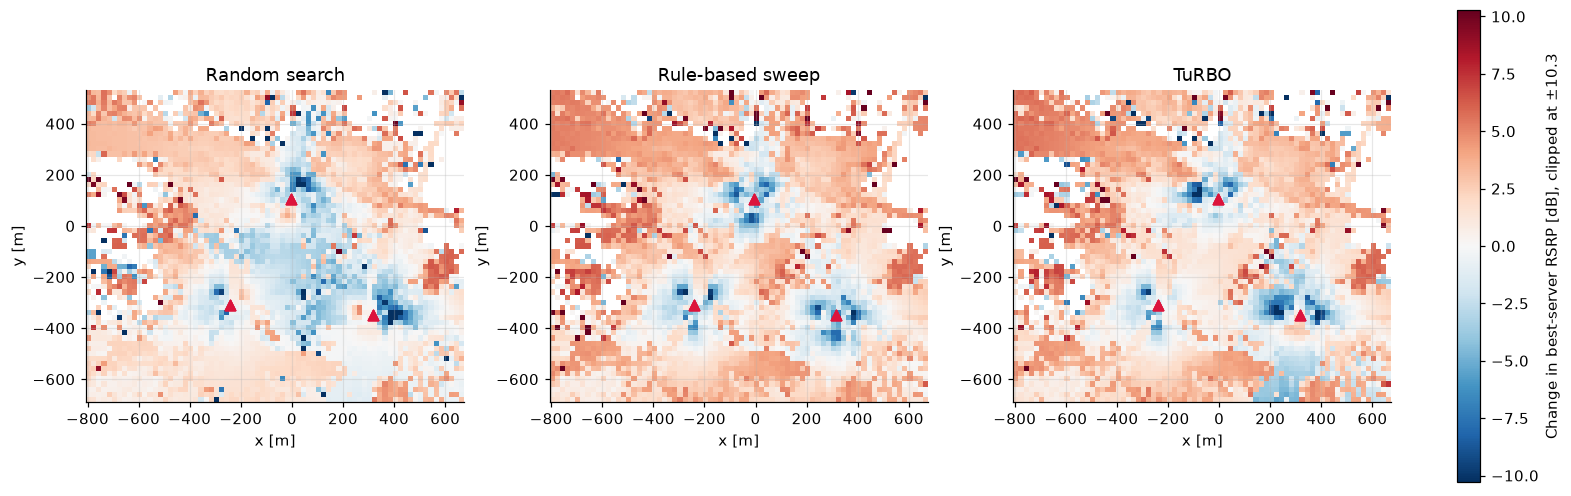

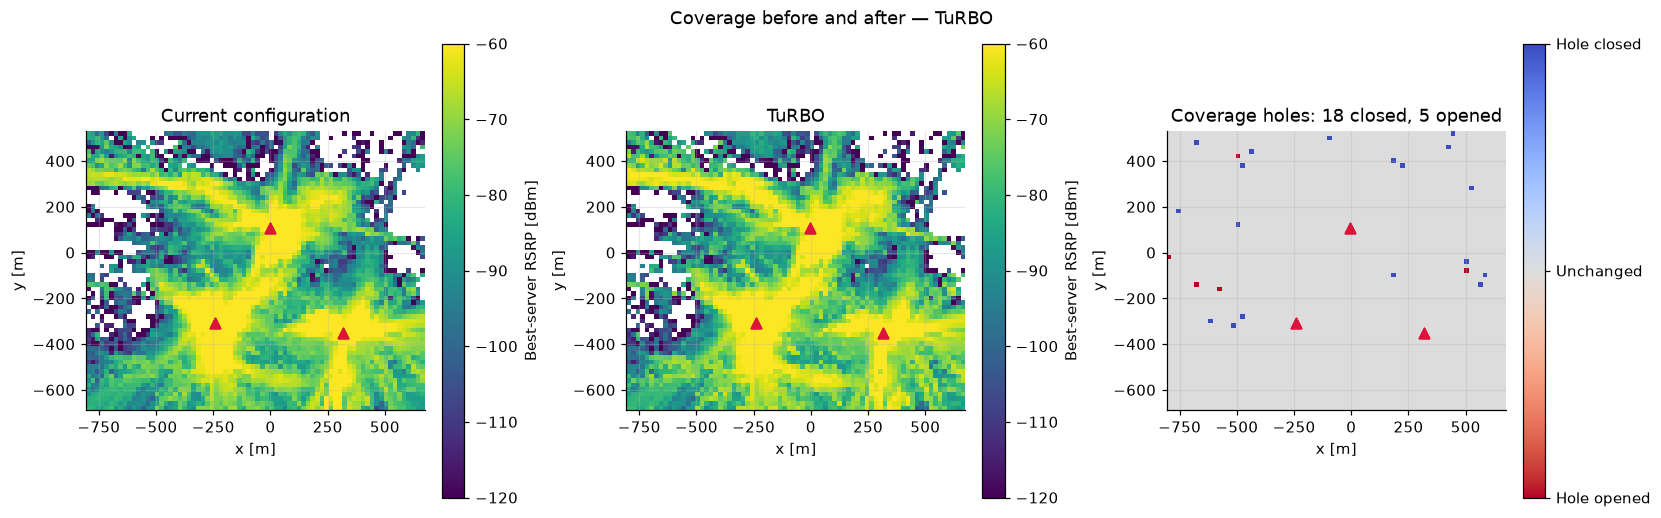

,Coverage class,Current configuration: Share of area,Current configuration: Share of demand,Random search: Share of area,Random search: Share of demand,Rule-based sweep: Share of area,Rule-based sweep: Share of demand,TuRBO: Share of area,TuRBO: Share of demand
0,hole,0.1768,0.0000,0.1755,0.0021,0.1719,0.0120,0.1739,0.0216
1,weak,0.1739,0.7599,0.1549,0.7550,0.1422,0.7217,0.1436,0.7021
2,good,0.6493,0.2401,0.6697,0.2428,0.6859,0.2663,0.6825,0.2764


In [7]:
display(results["rsrp_change_maps"])
display(results["coverage_before_after"])
display(results["coverage_by_area_and_demand"])

**Observations.** _To be written._

## 5. Capacity Impact

Capacity settings are placeholders, so read the direction of change rather than absolute values.

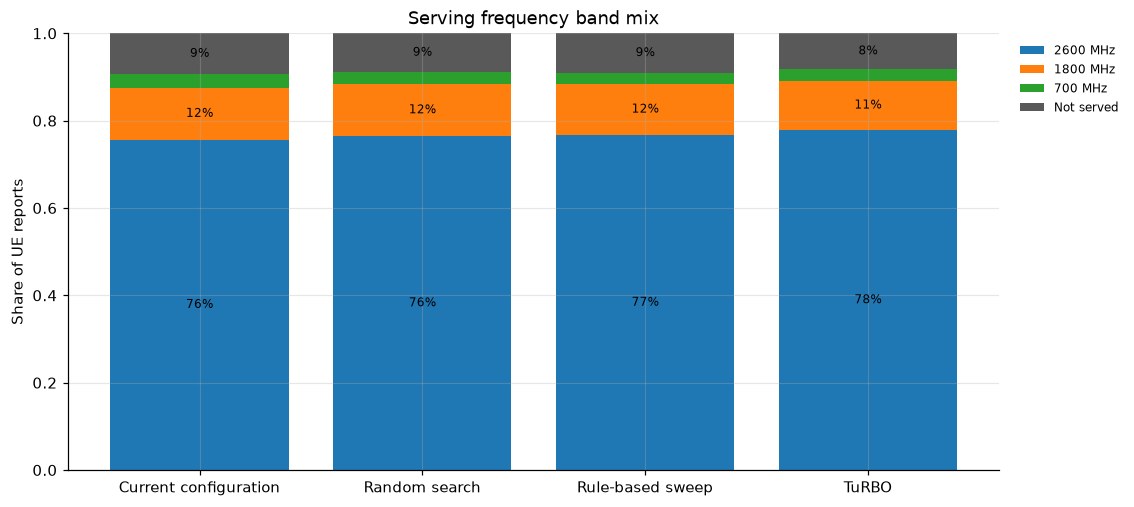

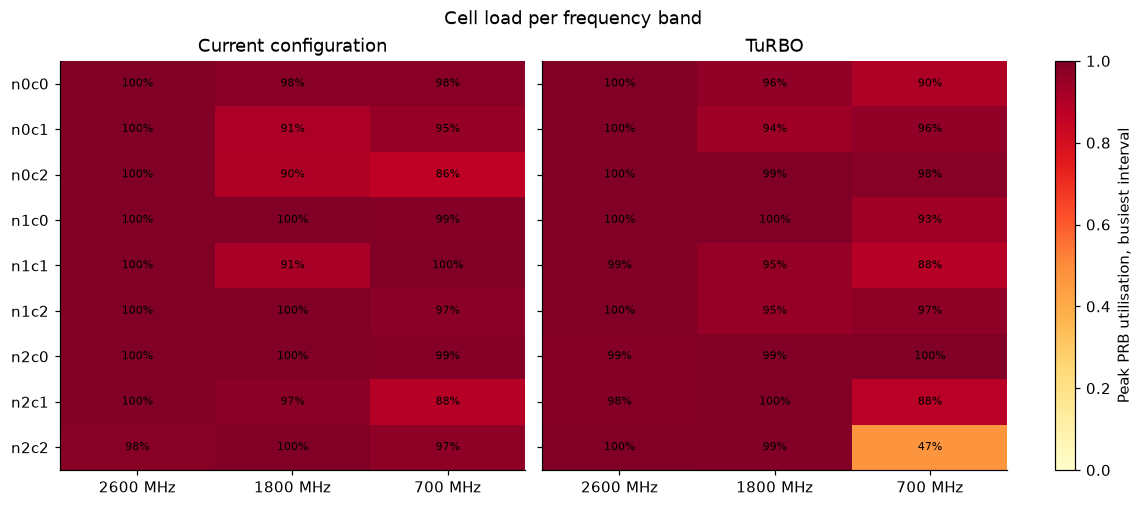

,Configuration,UE reports,Share not served,"Served SINR, 10th percentile [dB]","Served SINR, median [dB]","PRBs per served UE, median",Share served on 2600 MHz,Share served on 1800 MHz,Share served on 700 MHz
0,Current configuration,9202.0,0.0935,-0.5853,5.9725,48.1173,0.7567,0.1186,0.0313
1,Random search,9202.0,0.0885,-0.3388,6.1151,47.3396,0.7643,0.1196,0.0276
2,Rule-based sweep,9202.0,0.0900,-0.3832,5.9745,48.1066,0.7667,0.1180,0.0253
3,TuRBO,9202.0,0.0819,-0.1515,7.1167,42.4053,0.7782,0.1136,0.0263


In [8]:
display(results["serving_band_mix"])
display(results["cell_band_utilisation"])
display(results["ue_service_summary"])

**Observations.** _To be written._

## 6. Recommended Tilt Changes

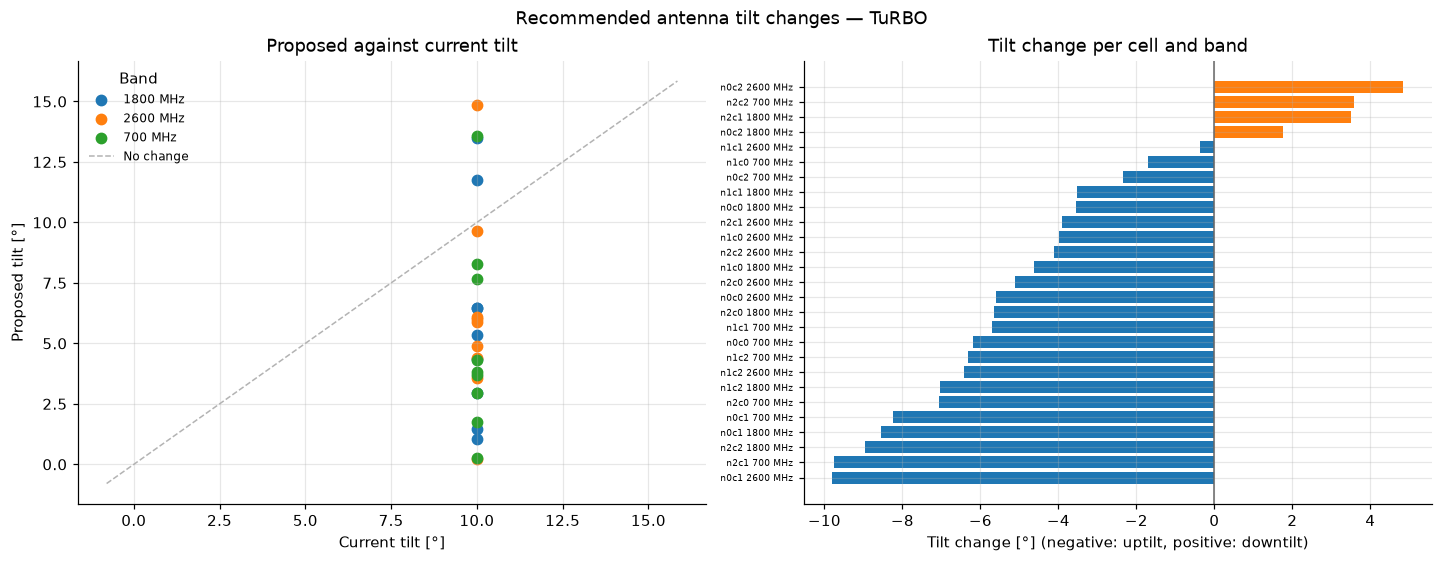

,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,9,9,5.2406,8.9682,-4.0718
1,2600 MHz,9,9,4.9073,9.7926,-3.8305
2,700 MHz,9,9,5.6519,9.7419,-4.8578


,Node,Cell,Azimuth [°],Band,Current tilt [°],Proposed tilt [°],Tilt change [°],"Served reports, before","Peak PRB utilisation, before",Median SINR before [dB],"Served reports, after","Peak PRB utilisation, after",Median SINR after [dB],"Served reports, change","Peak PRB utilisation, change",Median SINR change [dB]
0,n0,n0c0,30.0,2600 MHz,10.0,4.4045,-5.5955,1017,0.9987,4.7796,1328,0.9995,8.5319,311,0.0009,3.7523
1,n1,n1c0,30.0,2600 MHz,10.0,6.0052,-3.9948,884,0.9998,2.2083,1044,0.9979,2.9627,160,-0.0020,0.7544
2,n0,n0c1,150.0,2600 MHz,10.0,0.2074,-9.7926,901,0.9983,14.0047,774,0.9966,17.5491,-127,-0.0016,3.5444
3,n0,n0c2,270.0,2600 MHz,10.0,14.8454,4.8454,499,0.9992,2.7288,375,0.9959,2.8310,-124,-0.0032,0.1022
4,n1,n1c2,270.0,2600 MHz,10.0,3.5678,-6.4322,1358,0.9969,7.7148,1264,0.9987,8.0987,-94,0.0018,0.3839
5,n2,n2c0,30.0,2600 MHz,10.0,4.8978,-5.1022,655,0.9980,5.6358,729,0.9854,6.6800,74,-0.0126,1.0441
6,n2,n2c1,150.0,2600 MHz,10.0,6.0812,-3.9188,599,0.9997,5.0562,632,0.9847,5.5333,33,-0.0150,0.4771
7,n2,n2c0,30.0,700 MHz,10.0,2.9443,-7.0557,130,0.9852,9.9284,97,0.9955,11.5630,-33,0.0103,1.6346
8,n1,n1c0,30.0,1800 MHz,10.0,5.3653,-4.6347,190,0.9998,4.3910,222,0.9974,5.1249,32,-0.0024,0.7339
9,n1,n1c1,150.0,2600 MHz,10.0,9.6370,-0.3630,721,0.9994,7.7522,696,0.9942,8.6055,-25,-0.0052,0.8533


In [9]:
display(results["tilt_movement"])
display(results["tilt_movement_summary"])
display(results["cell_impact"])

**Observations.** _To be written._

## 7. Search Cost and Progress

,Method,Seed,Run,Evaluations,Best evaluation,Ray tracing [min],Wall clock [min],Coverage hole rate,Co-band overlap rate,Served UE ratio,Weak coverage rate,Cell-edge RSRP,Coverage desirability,Layer separation desirability,"Served desirability, per tile",Quality index,KPIs improved,KPIs worsened
0,Random search,42,2026-09-16_08-25-34,145,18,7.3080,8.8794,0.1755,0.3186,0.9115,0.1549,-104.6967,0.8249,0.9003,0.8659,0.8562,8,0
1,Rule-based sweep,42,2026-09-16_08-34-27,28,12,1.1436,1.4525,0.1719,0.3314,0.9100,0.1422,-103.9616,0.8281,0.8977,0.8685,0.8574,7,1
2,TuRBO,42,2026-09-16_08-36-09,145,140,9.4966,15.4831,0.1739,0.3161,0.9181,0.1436,-104.1787,0.8262,0.9078,0.8765,0.8610,8,0


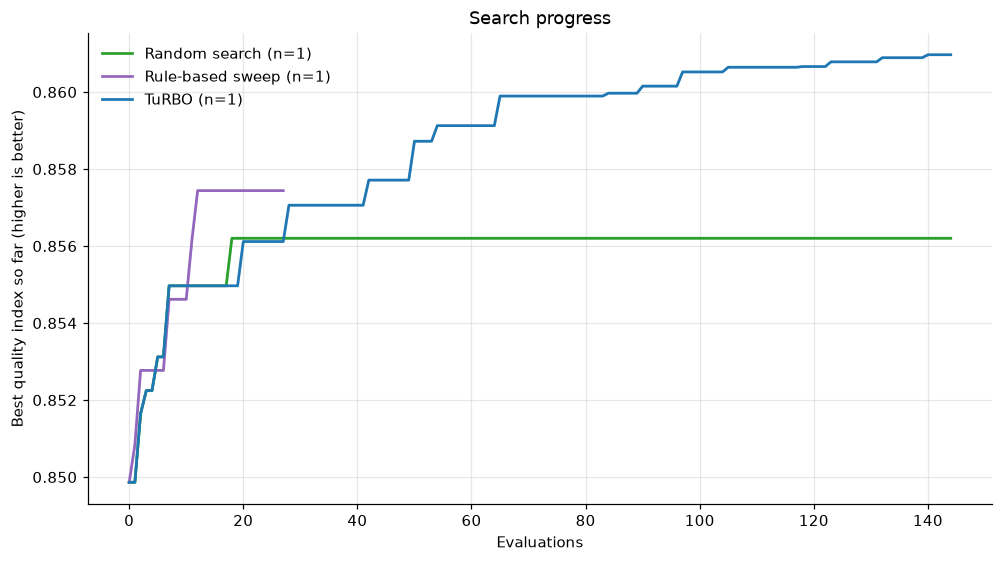

In [10]:
display(results["method_cost"])
display(results["search_progress"])

**Observations.** _To be written._

## 8. Threats to Validity

| # | Threat | Evidence | Status |
|---|---|---|---|
| 1 | One scenario: every configuration is tuned and scored on the same city and population, so no result measures generalisation | — | Open: held-out scenarios are not implemented |
| 2 | Winner's curse: the best of many evaluations under one solver seed is biased upward | — | Open: re-tracing under other solver seeds is not implemented |
| 3 | Weak reference: the current configuration uses identical default tilts, and the 2600 MHz tilt starts at its upper bound | Section 3, winner against candidates; notebook 02, decision variables | Mitigated |
| 4 | Too few runs to compare methods | Sections 2 and 3, intervals and paired test over seeds | Mitigated; power remains limited by the number of seeds |
| 5 | The objective depends on judgement parameters (tau_R, beta, rho_0, alpha, gamma) | — | Open: no sensitivity analysis |
| 6 | Hole and weak rates count area, including area without users | Section 4, coverage by area and by demand | Reported |
| 7 | The served ratio relies on placeholder capacity settings; UEs no cell reaches count as not served | Notebook 01, data quality | Open |
| 8 | Physical simplifications: full-load SINR, Shannon rate without MCS, no calibration against field measurements, reported RSRP below the 3GPP reporting range | Notebook 01, data quality | Open |
| 9 | The project title names Multi-Agent Reinforcement Learning, which is not implemented | — | Open |
| 10 | The rule-based sweep is not budget-matched; tilt movement and operational cost are not constrained | Sections 6 and 7 | Reported |